In [3]:
import pandas as pd

df = pd.read_parquet("../Data/cta_hits_1.parquet")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Columns:")
for col in df.columns:
    print(f"  {col}")

Shape: 82401 rows x 60 columns

Columns:
  message
  @version
  @timestamp
  service.instance
  service.name
  cta.message
  cta.readWriteTime
  cta.fSeq
  cta.program
  cta.userFilesCount
  cta.verifiedBytesCount
  cta.repackBytesCount
  cta.isVerifyOnly
  cta.epoch_time
  cta.fileId
  cta.drive_name
  cta.driveTransferSpeedMBps
  cta.tapePool
  cta.mediaType
  cta.tid
  cta.verifiedFilesCount
  cta.tapeVid
  cta.totalTime
  cta.positionTime
  cta.waitFreeMemoryTime
  cta.mountId
  cta.BlockId
  cta.LBPMode
  cta.environment
  cta.dataVolume
  cta.vo
  cta.thread
  cta.payloadTransferSpeedMBps
  cta.instance
  cta.hostname
  cta.labelFormat
  cta.vendor
  cta.repackFilesCount
  cta.log_level
  cta.pid
  cta.tapeDrive
  cta.headerVolume
  cta.checksumType
  cta.transferTime
  cta.logicalLibrary
  cta.mountType
  cta.capacityInBytes
  cta.userBytesCount
  cta.checksumValue
  cta.local_time
  cta.isRepack
  cta.dstURL
  cta.waitReportingTime
  cta.sched_backend
  landscape.kafka.offset
 

In [4]:
print("Time range in df:")
print(f"  @timestamp:     {df['@timestamp'].min()}  →  {df['@timestamp'].max()}")
print(f"  cta.local_time: {df['cta.local_time'].min()}  →  {df['cta.local_time'].max()}")

Time range in df:
  @timestamp:     2026-03-06T20:01:28.414Z  →  2026-04-03T12:03:06.499Z
  cta.local_time: 2026-03-06T14:01:21-0600  →  2026-04-03T07:02:59-0500


In [5]:
df['cta.local_time_converted'] = pd.to_datetime(df['cta.epoch_time'], unit='s', utc=True)

In [6]:
# First 10 rows — transpose to read long column names more easily
df.head(10).T
df.head(3).T.to_csv("columns_preview.csv")
print("Saved columns_preview.csv")

Saved columns_preview.csv


In [7]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82401 entries, 0 to 82400
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype              
---  ------                          --------------  -----              
 0   message                         82401 non-null  object             
 1   @version                        82401 non-null  object             
 2   @timestamp                      82401 non-null  object             
 3   service.instance                82401 non-null  object             
 4   service.name                    82401 non-null  object             
 5   cta.message                     82401 non-null  object             
 6   cta.readWriteTime               82401 non-null  float64            
 7   cta.fSeq                        82401 non-null  int64              
 8   cta.program                     82401 non-null  object             
 9   cta.userFilesCount              82401 non-null  int64              
 10  cta.verifi

In [8]:
df['cta.tapePool'].unique()

array(['cms.Run2025EPrompt', 'cms.cmsMC2024', 'cms.HIRun2023ARAW',
       'cms.cmsData2026', 'cms.cms11', 'cms.pORun2025RAW',
       'cms.cmsMC2025', 'cms.Run2024APrompt', 'cms.OORun2025Prompt',
       'cms.Run2011A', 'cms.Run2017FRAW', 'cms.Run2025ERAW',
       'cms.Run2024EPrompt', 'cms.Run2024BPrompt', 'cms.Run2024CPrompt',
       'cms.Run2024DPrompt', 'cms.Run2023CPrompt', 'cms.Run2025DPrompt',
       'cms.Run2022CPrompt', 'cms.Run2025BPrompt', 'cms.Run2025CPrompt'],
      dtype=object)

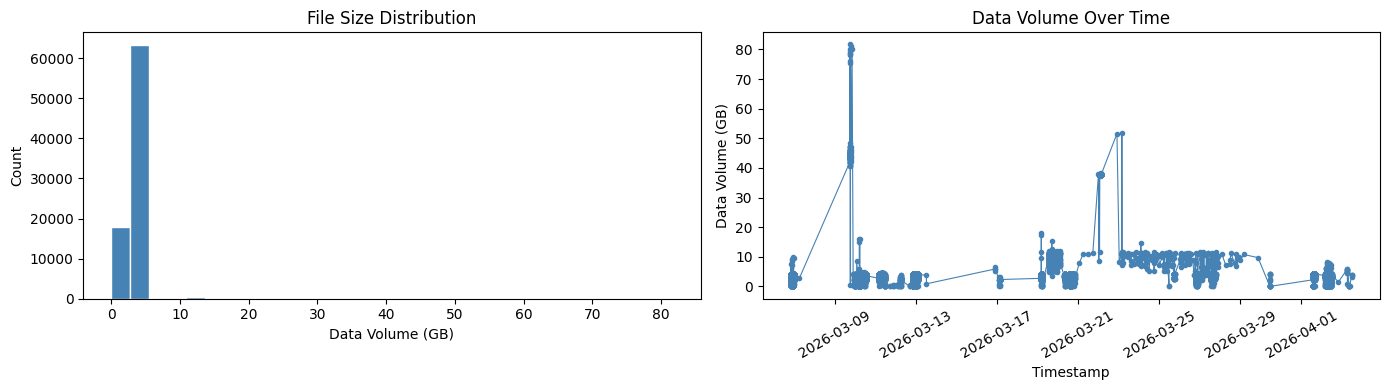


Stats (GB):
count    82401.000
mean         3.492
std          2.478
min          0.000
25%          2.834
50%          3.407
75%          3.931
max         81.668
Name: cta.dataVolume, dtype: float64


In [9]:
import matplotlib.pyplot as plt

# Convert bytes to GB for readability
data_gb = df["cta.dataVolume"] / 1e9

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Histogram: distribution of file sizes ---
axes[0].hist(data_gb, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("File Size Distribution")
axes[0].set_xlabel("Data Volume (GB)")
axes[0].set_ylabel("Count")

# --- Time series: data volume over time ---
ts = pd.to_datetime(df["@timestamp"]).sort_values()
axes[1].plot(ts, df.loc[ts.index, "cta.dataVolume"] / 1e9,
             marker="o", markersize=3, linewidth=0.8, color="steelblue")
axes[1].set_title("Data Volume Over Time")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Data Volume (GB)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"\nStats (GB):\n{data_gb.describe().round(3)}")

This example show that if recall hit a bunch of collocated files the position time is very small < 1

In [10]:
df[df["cta.mountId"] == "421285"][["cta.fSeq", "cta.positionTime","cta.local_time","cta.mediaType","cta.labelFormat","cta.payloadTransferSpeedMBps"]].sort_values("cta.local_time")

,cta.fSeq,cta.positionTime,cta.local_time,cta.mediaType,cta.labelFormat,cta.payloadTransferSpeedMBps


In [11]:
df_s = df.sort_values(["cta.mountId", "cta.local_time"]).reset_index(drop=True)
df_s["fSeq_diff"] = df_s.groupby("cta.mountId")["cta.fSeq"].diff()

In [12]:
df_s[df_s["cta.mountId"] == "421285"][["cta.fSeq", "fSeq_diff", "cta.positionTime","cta.local_time","cta.mediaType","cta.labelFormat","cta.payloadTransferSpeedMBps"]].sort_values("cta.local_time")

,cta.fSeq,fSeq_diff,cta.positionTime,cta.local_time,cta.mediaType,cta.labelFormat,cta.payloadTransferSpeedMBps


In [13]:
print(df["cta.mediaType"].unique())
print(df["cta.mediaType"].value_counts())

['LTO9' 'LTO8' 'LTO7M']
cta.mediaType
LTO9     49039
LTO8     18118
LTO7M    15244
Name: count, dtype: int64


In [14]:
print(df["cta.labelFormat"].unique())
print(df["cta.labelFormat"].dtype)
print(df["cta.labelFormat"].value_counts())

['0000' '0x02' '0x03']
object
cta.labelFormat
0000    47620
0x02    34252
0x03      529
Name: count, dtype: int64


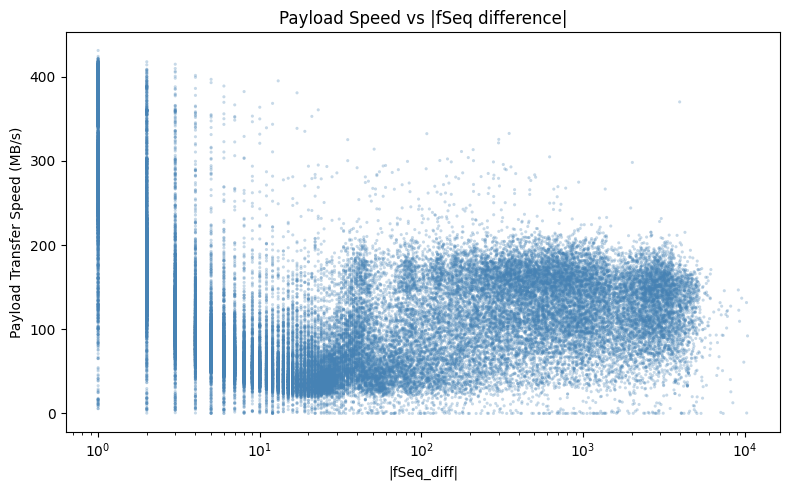

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_s[["fSeq_diff", "cta.payloadTransferSpeedMBps"]].dropna()
df_plot = df_plot[df_plot["fSeq_diff"] > 0]  # drop NaN rows (first row per mount) and 0

fig, ax = plt.subplots(figsize=(8, 5))
#ax.scatter(df_plot["fSeq_diff"].abs(), df_plot["cta.payloadTransferSpeedMBps"],
ax.scatter(df_plot["fSeq_diff"], df_plot["cta.payloadTransferSpeedMBps"],
           alpha=0.3, s=5, color="steelblue", edgecolors="none")
ax.set_xlabel("|fSeq_diff|")
ax.set_ylabel("Payload Transfer Speed (MB/s)")
ax.set_title("Payload Speed vs |fSeq difference| (positive only)")
ax.set_xscale("log")
plt.tight_layout()
plt.show()

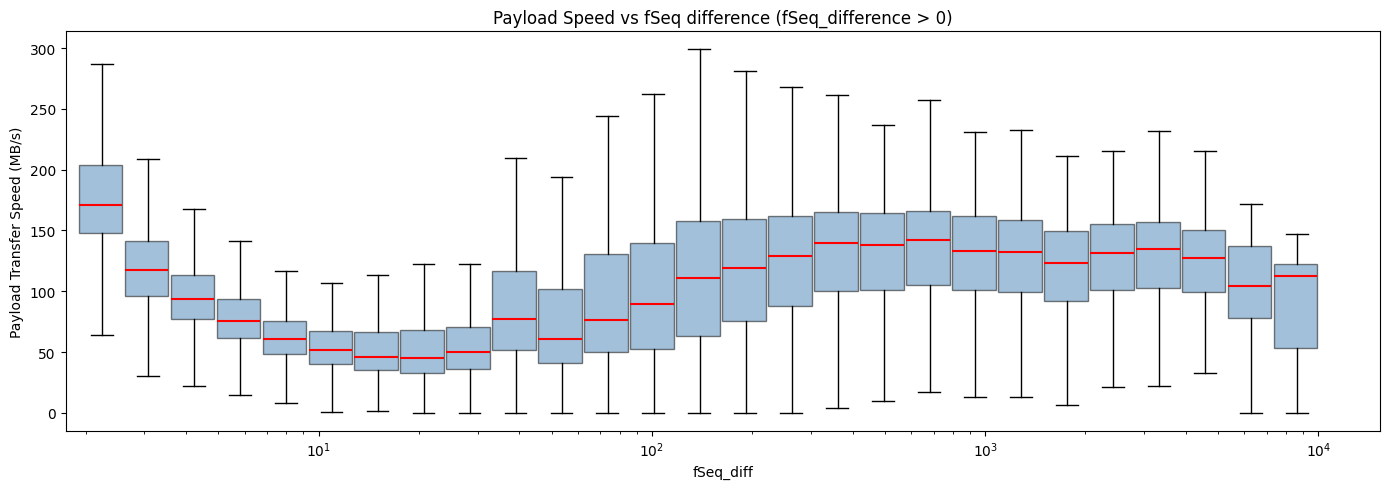

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_s[["fSeq_diff", "cta.payloadTransferSpeedMBps"]].dropna()
df_plot = df_plot[df_plot["fSeq_diff"] > 0].copy()

# Bin |fSeq_diff| in log scale
bins = np.logspace(0, 4, 30)  # 1 to 10000
#df_plot["diff_bin"] = pd.cut(df_plot["fSeq_diff"].abs(), bins=bins)
df_plot["diff_bin"] = pd.cut(df_plot["fSeq_diff"], bins=bins)

groups = df_plot.groupby("diff_bin", observed=True)["cta.payloadTransferSpeedMBps"].apply(list)
centers = [interval.mid for interval in groups.index]
data    = groups.values.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot(data, positions=centers, widths=[c * 0.3 for c in centers],
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.5),
           medianprops=dict(color="red", linewidth=1.5))

ax.set_xscale("log")
ax.set_xlabel("fSeq_diff")
ax.set_ylabel("Payload Transfer Speed (MB/s)")
ax.set_title("Payload Speed vs fSeq difference (fSeq_difference > 0)")
plt.tight_layout()
plt.show()

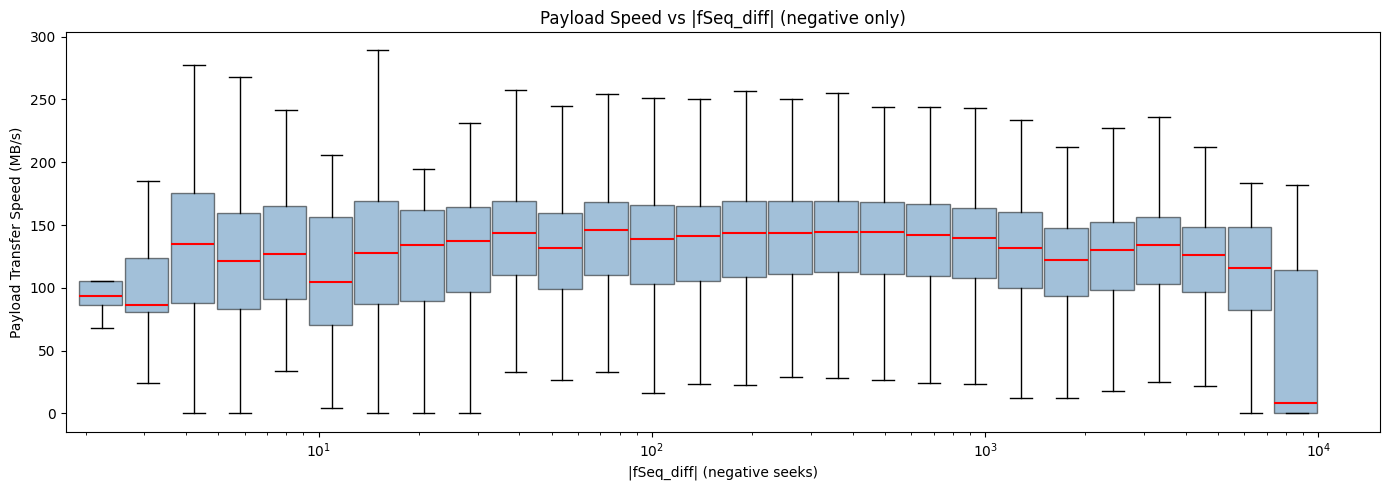

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_s[["fSeq_diff", "cta.payloadTransferSpeedMBps"]].dropna()
df_plot = df_plot[df_plot["fSeq_diff"] < 0].copy()
df_plot["fSeq_diff_abs"] = df_plot["fSeq_diff"].abs()

bins = np.logspace(0, 4, 30)
df_plot["diff_bin"] = pd.cut(df_plot["fSeq_diff_abs"], bins=bins)

groups = df_plot.groupby("diff_bin", observed=True)["cta.payloadTransferSpeedMBps"].apply(list)
groups = groups[groups.apply(len) > 0]  # drop empty bins
centers = [interval.mid for interval in groups.index]
data    = groups.values.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot(data, positions=centers, widths=[c * 0.3 for c in centers],
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.5),
           medianprops=dict(color="red", linewidth=1.5))

ax.set_xscale("log")
ax.set_xlabel("|fSeq_diff| (negative seeks)")
ax.set_ylabel("Payload Transfer Speed (MB/s)")
ax.set_title("Payload Speed vs |fSeq_diff| (negative only)")
plt.tight_layout()
plt.show()

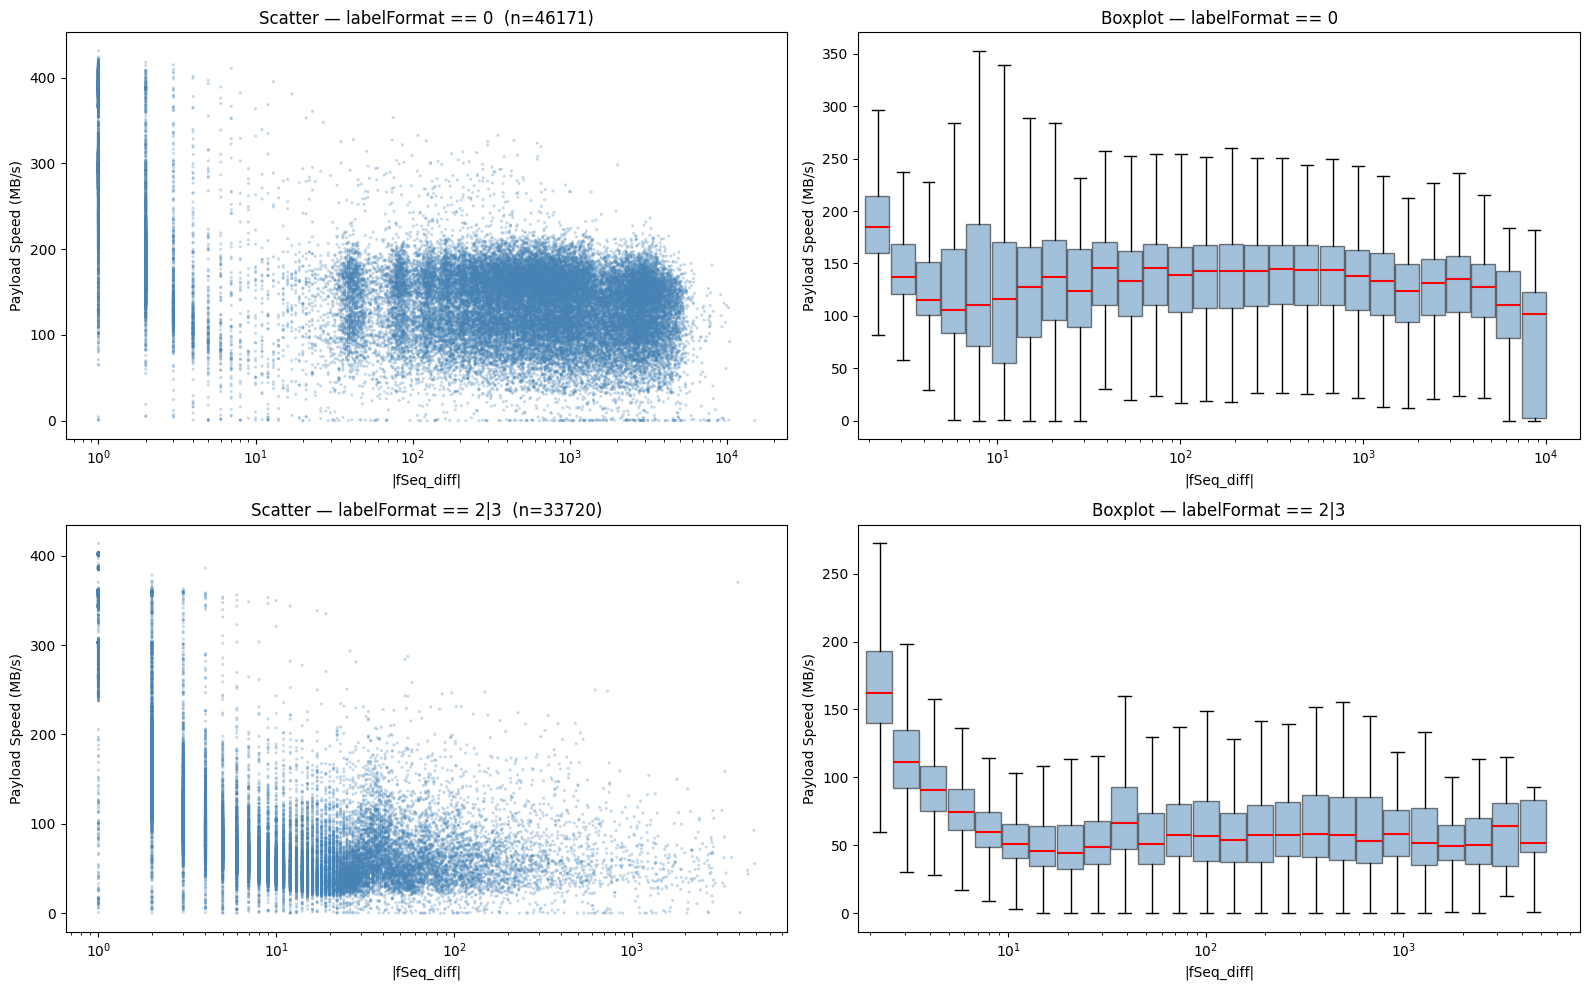

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
#lableFormat == 0 vs 2|3: 0: CTA, 2|3 are something enstore?
df_plot = df[["cta.mountId","cta.local_time","cta.fSeq",
              "cta.payloadTransferSpeedMBps","cta.labelFormat"]].copy()
df_plot = df_plot.sort_values(["cta.mountId","cta.local_time"]).reset_index(drop=True)
df_plot["fSeq_diff"] = df_plot.groupby("cta.mountId")["cta.fSeq"].diff()
df_plot = df_plot[df_plot["fSeq_diff"].notna()].copy()

groups = {
    "labelFormat == 0":   df_plot[df_plot["cta.labelFormat"] == "0000"],
    "labelFormat == 2|3": df_plot[df_plot["cta.labelFormat"].isin(["0x02", "0x03"])],
}

bins = np.logspace(0, 4, 30)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (label, data) in enumerate(groups.items()):
    data = data[data["fSeq_diff"].abs() > 0].copy()
    x = data["fSeq_diff"].abs()
    y = data["cta.payloadTransferSpeedMBps"]

    # --- Scatter ---
    axes[row, 0].scatter(x, y, alpha=0.3, s=5, color="steelblue", edgecolors="none")
    axes[row, 0].set_xscale("log")
    axes[row, 0].set_xlabel("|fSeq_diff|")
    axes[row, 0].set_ylabel("Payload Speed (MB/s)")
    axes[row, 0].set_title(f"Scatter — {label}  (n={len(data)})")

    # --- Box plot ---
    data["diff_bin"] = pd.cut(x, bins=bins)
    grp = data.groupby("diff_bin", observed=True)["cta.payloadTransferSpeedMBps"].apply(list)

    # Filter out empty bins
    non_empty = [(iv.mid, v) for iv, v in zip(grp.index, grp.values) if len(v) > 0]
    if non_empty:
        centers, vals = zip(*non_empty)
        axes[row, 1].boxplot(vals, positions=list(centers), widths=[c * 0.3 for c in centers],
                             showfliers=False, patch_artist=True,
                             boxprops=dict(facecolor="steelblue", alpha=0.5),
                             medianprops=dict(color="red", linewidth=1.5))
    axes[row, 1].set_xscale("log")
    axes[row, 1].set_xlabel("|fSeq_diff|")
    axes[row, 1].set_ylabel("Payload Speed (MB/s)")
    axes[row, 1].set_title(f"Boxplot — {label}")

plt.tight_layout()
plt.show()

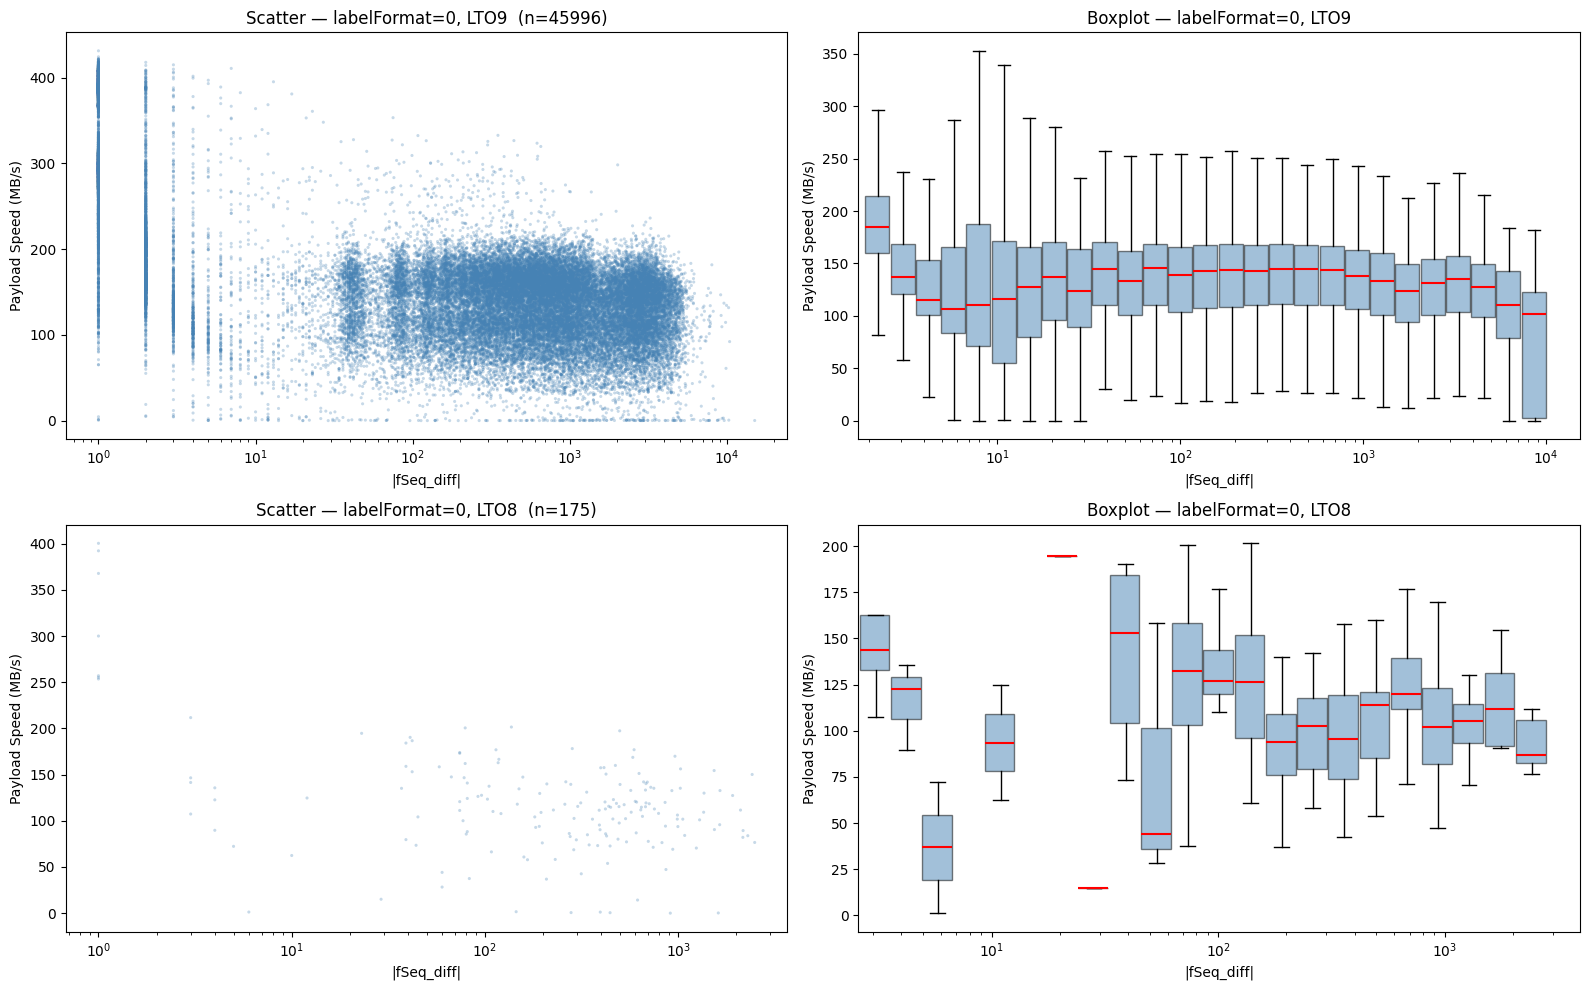

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df[["cta.mountId","cta.local_time","cta.fSeq",
              "cta.payloadTransferSpeedMBps","cta.labelFormat","cta.mediaType"]].copy()
df_plot = df_plot.sort_values(["cta.mountId","cta.local_time"]).reset_index(drop=True)
df_plot["fSeq_diff"] = df_plot.groupby("cta.mountId")["cta.fSeq"].diff()
df_plot = df_plot[df_plot["fSeq_diff"].notna()].copy()

# Base filter: labelFormat == 0
base = df_plot[df_plot["cta.labelFormat"] == "0000"]  # use int 0 if dtype is int

groups = {
    "labelFormat=0, LTO9": base[base["cta.mediaType"] == "LTO9"],
    "labelFormat=0, LTO8": base[base["cta.mediaType"] == "LTO8"],
}

bins = np.logspace(0, 4, 30)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (label, data) in enumerate(groups.items()):
    data = data[data["fSeq_diff"].abs() > 0].copy()
    x = data["fSeq_diff"].abs()
    y = data["cta.payloadTransferSpeedMBps"]

    # --- Scatter ---
    axes[row, 0].scatter(x, y, alpha=0.3, s=5, color="steelblue", edgecolors="none")
    axes[row, 0].set_xscale("log")
    axes[row, 0].set_xlabel("|fSeq_diff|")
    axes[row, 0].set_ylabel("Payload Speed (MB/s)")
    axes[row, 0].set_title(f"Scatter — {label}  (n={len(data)})")

    # --- Box plot ---
    data["diff_bin"] = pd.cut(x, bins=bins)
    grp = data.groupby("diff_bin", observed=True)["cta.payloadTransferSpeedMBps"].apply(list)

    non_empty = [(iv.mid, v) for iv, v in zip(grp.index, grp.values) if len(v) > 0]
    if non_empty:
        centers, vals = zip(*non_empty)
        axes[row, 1].boxplot(vals, positions=list(centers), widths=[c * 0.3 for c in centers],
                             showfliers=False, patch_artist=True,
                             boxprops=dict(facecolor="steelblue", alpha=0.5),
                             medianprops=dict(color="red", linewidth=1.5))
    axes[row, 1].set_xscale("log")
    axes[row, 1].set_xlabel("|fSeq_diff|")
    axes[row, 1].set_ylabel("Payload Speed (MB/s)")
    axes[row, 1].set_title(f"Boxplot — {label}")

plt.tight_layout()
plt.show()

Just confirm that there are some transfers with very low position time

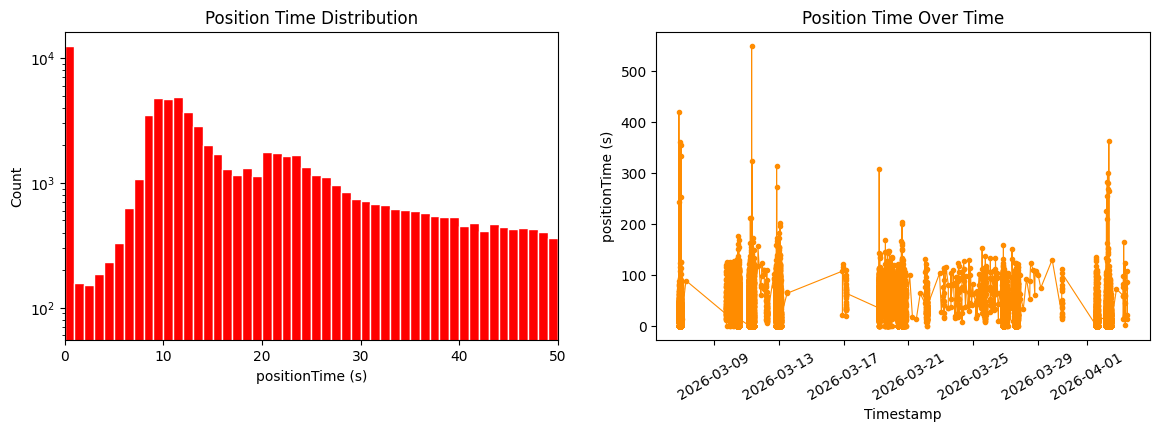


Stats (s):
count    82401.000
mean        23.256
std         23.385
min          0.000
25%          9.397
50%         14.724
75%         30.683
max        549.257
Name: cta.positionTime, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Histogram: distribution of positionTime ---
axes[0].hist(df["cta.positionTime"], bins=100, range=(0,100),color="red", edgecolor="white")
axes[0].set_title("Position Time Distribution")
axes[0].set_xlabel("positionTime (s)")
axes[0].set_ylabel("Count")
axes[0].set_yscale("log")
axes[0].set_xlim(0, 50) 

# --- Time series: positionTime over time ---
ts = pd.to_datetime(df["@timestamp"]).sort_values()
axes[1].plot(ts, df.loc[ts.index, "cta.positionTime"],
             marker="o", markersize=3, linewidth=0.8, color="darkorange")
axes[1].set_title("Position Time Over Time")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("positionTime (s)")
axes[1].tick_params(axis="x", rotation=30)

#plt.tight_layout()
plt.show()

print(f"\nStats (s):\n{df['cta.positionTime'].describe().round(3)}")

To make collocated groups:
1. Sort by mountId and local_time
2. Find transfers that has position time > 1. This is where the collocation breaks and significant time has spent for positioning. The is_seek tells if there was seeking (position tim > 1) or not. 
3. Make new col called group_id which is the cumsum of is_seek grouped by mountID. Since it is cumsum if there is no seeking or collocated this transfer is in the same group

Examples:

is_seek = df_s["cta.positionTime"] >= 1

is_seek is a boolean Series: True=1, False=0

[T, T, F, F, F, T, F, T, T, F]

[1, 1, 0, 0, 0, 1, 0, 1, 1, 0]



is_seek.groupby(df_s["cta.mountId"])

splits is_seek into chunks, one per mountId

so cumsum resets at each new mountId boundary



.cumsum()

cumulative sum within each mountId:

[1, 1, 0, 0, 0, 1, 0, 1, 1, 0]  ← is_seek values

[1, 2, 2, 2, 2, 3, 3, 4, 5, 5]  ← cumsum = group_id

So for a concrete example with mountId 421285:


positionTime   is_seek   group_id (cumsum)

15.9           True=1    1   ← seek → new group 1

21.4           True=1    2   ← seek → new group 2

20.6           True=1    3   ← seek → new group 3

0.04           False=0   3   ← collocated, stays in group 3

0.05           False=0   3   ← collocated, stays in group 3

11.7           True=1    4   ← seek → new group 4

Key insight: cumsum on booleans counts how many True values have been seen so far → each seek increments the group counter, non-seeks stay in the same group.

Before                              After .groupby().cumsum()

──────────────────────────────      ─────────────────────────────────────

mountId   positionTime  is_seek     mountId   positionTime  is_seek  group_id

421285    15.9          True        421285    15.9          True      1

421285    21.4          True        421285    21.4          True      2

421285    0.04          False       421285    0.04          False     2

421285    11.7          True        421285    11.7          True      3

421286    20.0          True        421286    20.0          True      1  ← resets

421286    0.05          False       421286    0.05          False     1

In [ ]:
# Sort by mountId then local_time
df_s = df[["cta.mountId","cta.local_time","cta.dataVolume","cta.fSeq","cta.totalTime","cta.transferTime","cta.readWriteTime","cta.positionTime",\
           "cta.driveTransferSpeedMBps","cta.payloadTransferSpeedMBps",
           "cta.logicalLibrary","cta.tapePool"]].copy()
df_s = df_s.sort_values(["cta.mountId", "cta.local_time"]).reset_index(drop=True)

# Group logic:
#   A new group starts at each row with positionTime >= 1 (the "seek").
#   That row owns all following consecutive rows with positionTime < 1 (sequential reads).
#   group_id = cumulative count of "seek" rows seen so far within each mountId.
is_seek = df_s["cta.positionTime"] >= 1
df_s["group_id"] = is_seek.groupby(df_s["cta.mountId"]).cumsum()

# Summarise each group
df_groups = (
    df_s.groupby(["cta.mountId", "group_id"])
    .agg(
        n_files_grp       = ("cta.fSeq",                      "count"),
        fSeq_list         = ("cta.fSeq",                      list),
        seek_time         = ("cta.positionTime",               "first"),
        posTime_min       = ("cta.positionTime",               "min"),
        posTime_max       = ("cta.positionTime",               "max"),
        sum_posTime       = ("cta.positionTime",               "sum"),
        sum_dataVolume    = ("cta.dataVolume",                 "sum"),
        sum_totalTime     = ("cta.totalTime",                  "sum"),
        sum_transferTime  = ("cta.transferTime",               "sum"),
        sum_readWriteTime = ("cta.readWriteTime",              "sum"),
        ave_payloadSpeed  = ("cta.payloadTransferSpeedMBps",   "mean"),
        ave_driveSpeed    = ("cta.driveTransferSpeedMBps",     "mean"),
        time_start        = ("cta.local_time",                 "min"),
        logicalLibrary    = ("cta.logicalLibrary",             lambda x: list(x.unique())),
        tapePool          = ("cta.tapePool",                   lambda x: list(x.unique())),
    )
    .round(3)
    .reset_index()
)

# Check assumption: are logicalLibrary and tapePool always single-valued per group?
multi_lib  = df_groups["logicalLibrary"].apply(len) > 1
multi_pool = df_groups["tapePool"].apply(len) > 1
print(f"{len(df_groups)} groups across {df_groups['cta.mountId'].nunique()} mounts")
print(f"Groups with multiple logicalLibrary values: {multi_lib.sum()}")
print(f"Groups with multiple tapePool values:       {multi_pool.sum()}")
df_groups

69863 groups across 2021 mounts
Groups with multiple logicalLibrary values: 0
Groups with multiple tapePool values:       0


,cta.mountId,group_id,n_files_grp,fSeq_list,seek_time,posTime_min,posTime_max,sum_posTime,sum_dataVolume,sum_totalTime,sum_transferTime,sum_readWriteTime,ave_payloadSpeed,ave_driveSpeed,time_start,logicalLibrary,tapePool
0,440331,1,1,[1801],38.927,38.927,38.927,38.927,2499032359,47.773,8.845,8.845,52.310,52.310,2026-03-06T14:01:56-0600,[F1_LTO9],[cms.Run2025DPrompt]
1,440331,2,1,[469],14.195,14.195,14.195,14.195,4113306292,27.167,12.971,12.970,151.409,151.409,2026-03-06T14:02:23-0600,[F1_LTO9],[cms.Run2025DPrompt]
2,440331,3,1,[1805],14.127,14.127,14.127,14.127,2560932031,22.934,8.806,8.805,111.666,111.666,2026-03-06T14:02:46-0600,[F1_LTO9],[cms.Run2025DPrompt]
3,440331,4,2,"[2840, 2841]",15.018,0.025,15.018,15.043,7895409891,39.597,24.552,24.548,231.489,231.489,2026-03-06T14:03:13-0600,[F1_LTO9],[cms.Run2025DPrompt]
4,440331,5,1,[1066],15.897,15.897,15.897,15.897,4109983413,28.989,13.091,13.090,141.777,141.777,2026-03-06T14:03:55-0600,[F1_LTO9],[cms.Run2025DPrompt]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69858,451810,1,1,[1578],74.728,74.728,74.728,74.728,22156663,74.898,0.170,0.170,0.296,0.296,2026-04-03T04:09:40-0500,[F1_LTO9],[cms.Run2024APrompt]
69859,451836,1,1,[1070],107.229,107.229,107.229,107.229,3826246095,119.704,12.474,12.471,31.964,31.964,2026-04-03T07:02:03-0500,[F1_LTO9],[cms.cmsData2026]
69860,451836,2,1,[1496],13.094,13.094,13.094,13.094,3838748671,26.279,13.184,13.181,146.077,146.077,2026-04-03T07:02:29-0500,[F1_LTO9],[cms.cmsData2026]
69861,451838,1,1,[1625],84.974,84.974,84.974,84.974,3714147735,94.848,9.873,9.871,39.159,39.159,2026-04-03T07:02:59-0500,[F1_LTO9],[cms.cmsData2026]


In [ ]:
df_groups[df_groups['cta.mountId']=='421285'].sort_values("time_start")

,cta.mountId,group_id,n_files_grp,fSeq_list,seek_time,posTime_min,posTime_max,sum_posTime,sum_dataVolume,sum_totalTime,sum_transferTime,sum_readWriteTime,ave_payloadSpeed,ave_driveSpeed,time_start,logicalLibrary,tapePool


Now group by mountId and do actual aggregation for interested metrics

In [ ]:
df_by_mount2 = (
    df_groups.groupby("cta.mountId")
    .agg(
        logicalLibrary   = ("logicalLibrary",  lambda x: list({v for vals in x for v in vals})),
        tapePool         = ("tapePool",         lambda x: list({v for vals in x for v in vals})),
        totFiles         = ("n_files_grp",          "sum"),
        totColFiles      = ("n_files_grp", lambda x: x[x > 1].sum()),
        totColGroups     = ("group_id",         "nunique"),
        avgcolgrsize     = ("n_files_grp",          "mean"),
        avgcolgrsizeGB   = ("sum_dataVolume", lambda x: round(x.mean() / (1024**3), 3)),
        avg_seek_time    = ("seek_time",          "mean"),
        avg_posTime_min  = ("posTime_min",         "mean"),
        avg_posTime_max  = ("posTime_max",         "mean"),
        total_posTime    = ("sum_posTime",         "sum"),
        total_rwTime     = ("sum_readWriteTime",   "sum"),
        avgcolgrpayloadSpeed = ("ave_payloadSpeed",    "mean"),
        avgcolgrdriveSpeed   = ("ave_driveSpeed",      "mean"),
        time_start       = ("time_start",          "min"),
    )
    .round(3)
    .reset_index()
)

# ratio: positionTime / (positionTime + readWriteTime)
df_by_mount2["poseffloss"] = (
    df_by_mount2["total_posTime"] /
    (df_by_mount2["total_posTime"] + df_by_mount2["total_rwTime"])
).round(3)
print(f"{len(df_by_mount2)} mounts")


2021 mounts


In [ ]:
print("logicalLibrary values:")
all_libs = {v for vals in df_by_mount2["logicalLibrary"] for v in vals}
for v in sorted(all_libs):
    print(f"  {v}")

print("\ntapePool values:")
all_pools = {v for vals in df_by_mount2["tapePool"] for v in vals}
for v in sorted(all_pools):
    print(f"  {v}")

logicalLibrary values:
  F1_LTO9
  G1_LTO8

tapePool values:
  cms.HIRun2023ARAW
  cms.OORun2025Prompt
  cms.Run2011A
  cms.Run2017FRAW
  cms.Run2022CPrompt
  cms.Run2023CPrompt
  cms.Run2024APrompt
  cms.Run2024BPrompt
  cms.Run2024CPrompt
  cms.Run2024DPrompt
  cms.Run2024EPrompt
  cms.Run2025BPrompt
  cms.Run2025CPrompt
  cms.Run2025DPrompt
  cms.Run2025EPrompt
  cms.Run2025ERAW
  cms.cms11
  cms.cmsData2026
  cms.cmsMC2024
  cms.cmsMC2025
  cms.pORun2025RAW


In [ ]:
df_by_mount2[df_by_mount2['avgcolgrsize']>=3]

,cta.mountId,logicalLibrary,tapePool,totFiles,totColFiles,totColGroups,avgcolgrsize,avgcolgrsizeGB,avg_seek_time,avg_posTime_min,avg_posTime_max,total_posTime,total_rwTime,avgcolgrpayloadSpeed,avgcolgrdriveSpeed,time_start,poseffloss
493,441594,[G1_LTO8],[cms.cms11],9,9,3,3.00,8.413,53.202,0.000,53.202,159.609,89.763,225.539,225.539,2026-03-10T06:01:38-0500,0.64
1934,450955,[F1_LTO9],[cms.Run2011A],99,86,25,3.96,12.555,41.979,20.048,41.979,1051.184,860.215,165.663,165.663,2026-04-01T09:14:34-0500,0.55


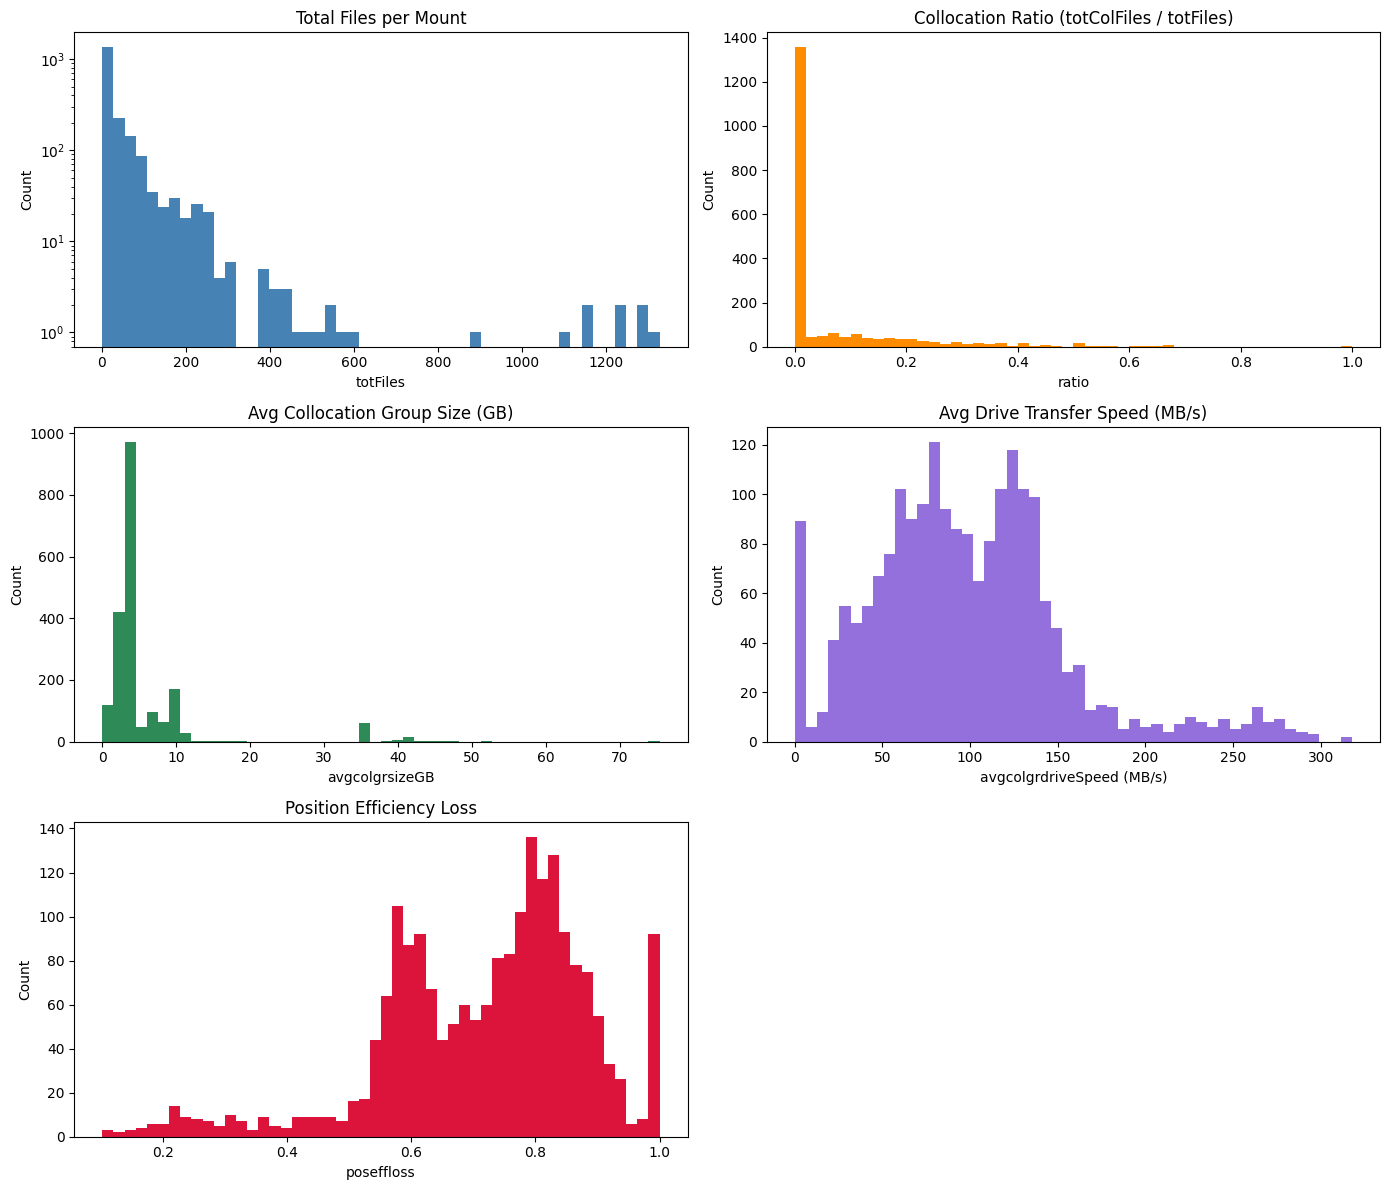

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# 1. Total files per mount
axes[0,0].hist(df_by_mount2["totFiles"], bins=50, color="steelblue", edgecolor="none")
axes[0,0].set_title("Total Files per Mount")
axes[0,0].set_xlabel("totFiles")
axes[0,0].set_ylabel("Count")
axes[0,0].set_yscale("log")

# 2. Collocation ratio: totColFiles / totFiles
ratio = df_by_mount2["totColFiles"] / df_by_mount2["totFiles"]
axes[0,1].hist(ratio, bins=50, color="darkorange", edgecolor="none")
axes[0,1].set_title("Collocation Ratio (totColFiles / totFiles)")
axes[0,1].set_xlabel("ratio")
axes[0,1].set_ylabel("Count")

# 3. Avg collocation group size (GB)
axes[1,0].hist(df_by_mount2["avgcolgrsizeGB"], bins=50, color="seagreen", edgecolor="none")
axes[1,0].set_title("Avg Collocation Group Size (GB)")
axes[1,0].set_xlabel("avgcolgrsizeGB")
axes[1,0].set_ylabel("Count")

# 4. Avg drive speed
axes[1,1].hist(df_by_mount2["avgcolgrdriveSpeed"], bins=50, color="mediumpurple", edgecolor="none")
axes[1,1].set_title("Avg Drive Transfer Speed (MB/s)")
axes[1,1].set_xlabel("avgcolgrdriveSpeed (MB/s)")
axes[1,1].set_ylabel("Count")

# 5. poseffloss
axes[2,0].hist(df_by_mount2["poseffloss"], bins=50, color="crimson", edgecolor="none")
axes[2,0].set_title("Position Efficiency Loss")
axes[2,0].set_xlabel("poseffloss")
axes[2,0].set_ylabel("Count")

# 6. empty — or remove with:
axes[2,1].set_visible(False)

plt.tight_layout()
plt.show()

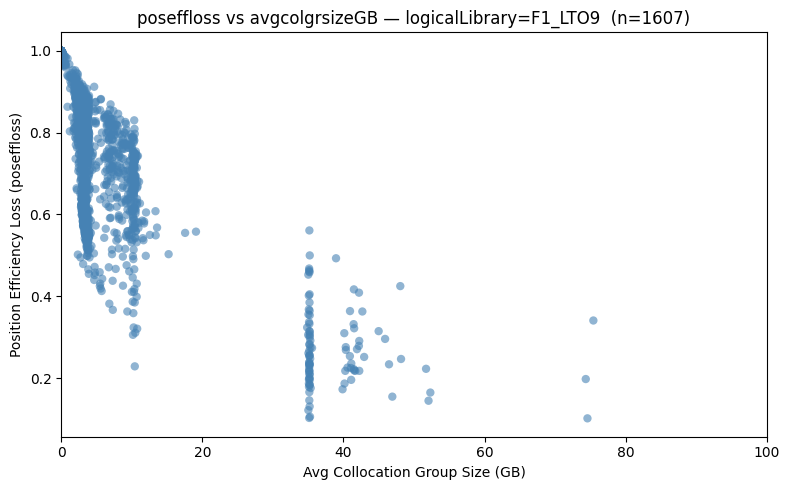

In [ ]:
mask = df_by_mount2["logicalLibrary"].apply(lambda x: "F1_LTO9" in x)
df_plot = df_by_mount2[mask]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_plot["avgcolgrsizeGB"], df_plot["poseffloss"],
           alpha=0.6, edgecolors="none", color="steelblue")
ax.set_xlabel("Avg Collocation Group Size (GB)")
ax.set_ylabel("Position Efficiency Loss (poseffloss)")
ax.set_xlim(0,100)
ax.set_title(f"poseffloss vs avgcolgrsizeGB — logicalLibrary=F1_LTO9  (n={len(df_plot)})")
plt.tight_layout()
plt.show()

Check why position efficiency loss so high

In [ ]:
df_plot[df_plot["poseffloss"] >= 0.9].sort_values("poseffloss", ascending=False)

,cta.mountId,logicalLibrary,tapePool,totFiles,totColFiles,totColGroups,avgcolgrsize,avgcolgrsizeGB,avg_seek_time,avg_posTime_min,avg_posTime_max,total_posTime,total_rwTime,avgcolgrpayloadSpeed,avgcolgrdriveSpeed,time_start,poseffloss
276,440667,[F1_LTO9],[cms.Run2025DPrompt],1,0,1,1.0,0.003,83.372,83.372,83.372,83.372,0.011,0.041,0.041,2026-03-06T17:18:57-0600,1.000
275,440666,[F1_LTO9],[cms.Run2025DPrompt],1,0,1,1.0,0.003,123.832,123.832,123.832,123.832,0.010,0.028,0.028,2026-03-06T17:18:06-0600,1.000
358,441345,[F1_LTO9],[cms.Run2025ERAW],1,0,1,1.0,0.001,73.340,73.340,73.340,73.340,0.005,0.018,0.018,2026-03-09T18:54:31-0500,1.000
361,441349,[F1_LTO9],[cms.Run2025ERAW],1,0,1,1.0,0.001,69.877,69.877,69.877,69.877,0.006,0.019,0.019,2026-03-09T18:57:50-0500,1.000
359,441347,[F1_LTO9],[cms.Run2025ERAW],1,0,1,1.0,0.000,21.119,21.119,21.119,21.119,0.002,0.007,0.007,2026-03-09T18:54:48-0500,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,448773,[F1_LTO9],[cms.Run2025EPrompt],1,0,1,1.0,2.597,97.054,97.054,97.054,97.054,10.416,25.949,25.949,2026-03-27T12:18:55-0500,0.903
338,441321,[F1_LTO9],[cms.cmsMC2024],10,0,10,1.0,2.053,54.598,54.598,54.598,545.981,59.032,39.139,39.139,2026-03-09T18:47:02-0500,0.902
880,444515,[F1_LTO9],[cms.Run2024EPrompt],9,0,9,1.0,2.298,63.485,63.485,63.485,571.363,62.414,45.474,45.474,2026-03-18T23:58:46-0500,0.902
1820,448770,[F1_LTO9],[cms.Run2025EPrompt],1,0,1,1.0,2.706,98.405,98.405,98.405,98.405,10.785,26.613,26.613,2026-03-27T12:15:14-0500,0.901


/tmp/ipykernel_561862/896031480.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["sizeGB_bin"] = pd.cut(df_plot["avgcolgrsizeGB"], bins=bins)


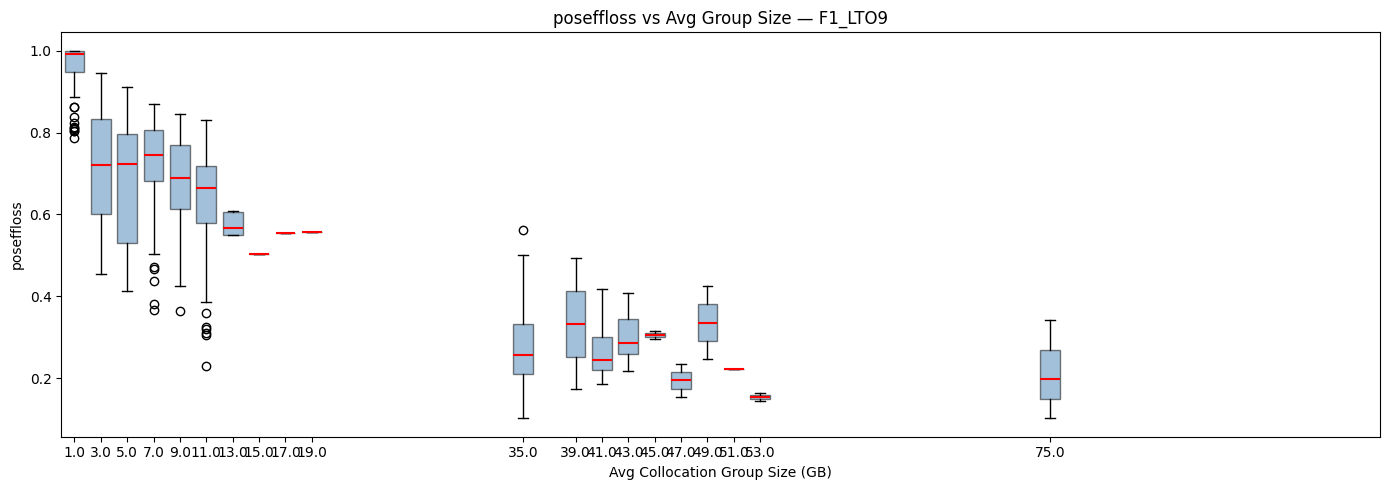

In [ ]:
import numpy as np

#mask = df_by_mount2["logicalLibrary"].apply(lambda x: "F1_LTO9" in x)
#df_plot = df_by_mount2[mask].copy()

# Bin x-axis
bins = np.linspace(0, 100, 51)
df_plot["sizeGB_bin"] = pd.cut(df_plot["avgcolgrsizeGB"], bins=bins)

# Collect poseffloss values per bin (only non-empty bins)
groups = df_plot.groupby("sizeGB_bin", observed=True)["poseffloss"].apply(list)
centers = [interval.mid for interval in groups.index]
data    = groups.values.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot(data, positions=centers, widths=1.5,
           showfliers=True, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.5),
           medianprops=dict(color="red", linewidth=1.5))

ax.set_xlabel("Avg Collocation Group Size (GB)")
ax.set_ylabel("poseffloss")
ax.set_title("poseffloss vs Avg Group Size — F1_LTO9")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

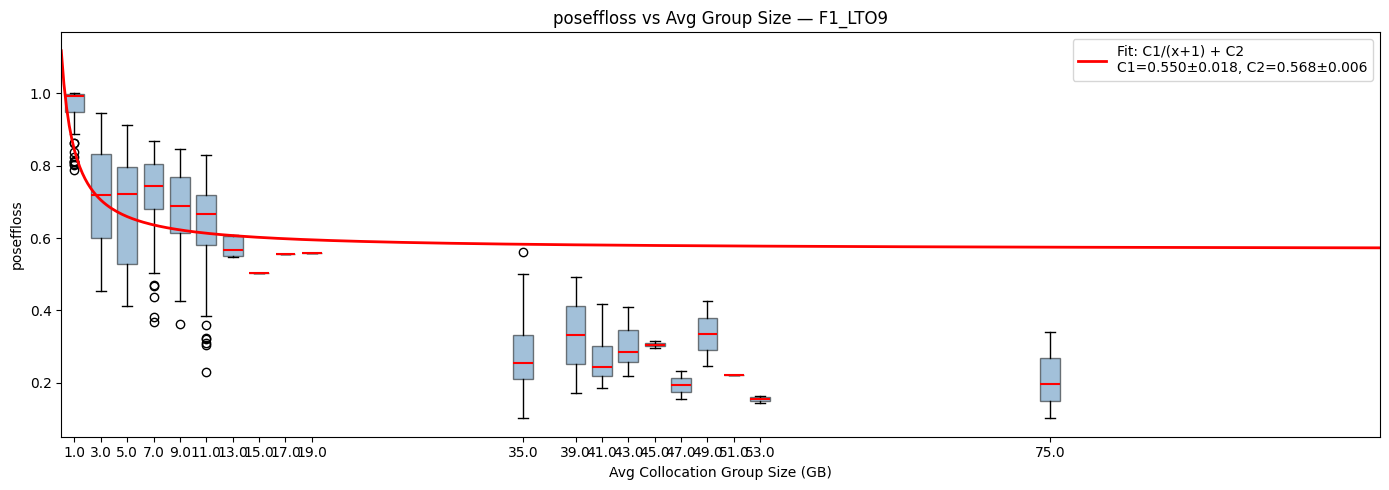

Fit: poseffloss = 0.5501 / (x+1) + 0.5677


In [ ]:
import numpy as np
from scipy.optimize import curve_fit

mask = df_by_mount2["logicalLibrary"].apply(lambda x: "F1_LTO9" in x)
df_plot = df_by_mount2[mask].copy()

# Bin x-axis
bins = np.linspace(0, 100, 51)
df_plot["sizeGB_bin"] = pd.cut(df_plot["avgcolgrsizeGB"], bins=bins)

# Collect per bin
groups  = df_plot.groupby("sizeGB_bin", observed=True)["poseffloss"].apply(list)
centers = np.array([interval.mid for interval in groups.index])
data    = groups.values.tolist()

# Box plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot(data, positions=centers, widths=1.5,
           showfliers=True, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.5),
           medianprops=dict(color="red", linewidth=1.5))

# --- Fit inverse power law: poseffloss = C1/(n+1) + C2 ---
# Use raw data points (not bin means) for a better fit
df_fit = df_plot[["avgcolgrsizeGB", "poseffloss"]].dropna()
x_data = df_fit["avgcolgrsizeGB"].values
y_data = df_fit["poseffloss"].values

def inv_power(x, C1, C2):
    return C1 / (x + 1) + C2

popt, pcov = curve_fit(inv_power, x_data, y_data, p0=[1.0, 0.0], maxfev=5000)
C1, C2 = popt
perr = np.sqrt(np.diag(pcov))  # standard errors on parameters

x_fit = np.linspace(0, 100, 500)
y_fit = inv_power(x_fit, *popt)
ax.plot(x_fit, y_fit, "r-", linewidth=2,
        label=f"Fit: C1/(x+1) + C2\nC1={C1:.3f}±{perr[0]:.3f}, C2={C2:.3f}±{perr[1]:.3f}")

ax.set_xlabel("Avg Collocation Group Size (GB)")
ax.set_ylabel("poseffloss")
ax.set_title("poseffloss vs Avg Group Size — F1_LTO9")
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Fit: poseffloss = {C1:.4f} / (x+1) + {C2:.4f}")

In [ ]:
# Group by mountId + consecutive fSeq runs
# Update these two variables if cell-5 showed different names
COL_MOUNT = "cta.mountId"
COL_FSEQ  = "cta.fSeq"

df_sorted = df[[COL_MOUNT, COL_FSEQ]].copy()
df_sorted = df_sorted.sort_values([COL_MOUNT, COL_FSEQ]).reset_index(drop=True)

# Flag where fSeq breaks consecutiveness within same mountId
df_sorted["is_break"] = (
    (df_sorted[COL_FSEQ].diff() != 1) |
    (df_sorted[COL_MOUNT] != df_sorted[COL_MOUNT].shift())
)

df_sorted["consec_group"] = df_sorted["is_break"].cumsum()

df_consec = (
    df_sorted.groupby([COL_MOUNT, "consec_group"])[COL_FSEQ]
    .agg(fSeq_start="min", fSeq_end="max", fSeq_count="count")
    .reset_index()
    .drop(columns="consec_group")
    .sort_values("fSeq_count", ascending=False)
    .reset_index(drop=True)
)

df_consec["fSeq_range"] = df_consec.apply(
    lambda r: str(int(r.fSeq_start)) if r.fSeq_count == 1
              else f"{int(r.fSeq_start)}-{int(r.fSeq_end)}",
    axis=1
)

print(f"{len(df_consec)} consecutive runs across {df_consec[COL_MOUNT].nunique()} mounts\n")
df_consec[[COL_MOUNT, "fSeq_range", "fSeq_count"]]

69196 consecutive runs across 2021 mounts



,cta.mountId,fSeq_range,fSeq_count
0,450955,2490-2523,34
1,450949,1884-1913,30
2,450949,391-418,28
3,450948,6158-6184,27
4,450952,3701-3725,25
...,...,...,...
69191,441904,2085,1
69192,441904,2089,1
69193,441904,2110,1
69194,441904,2112,1


In [ ]:
# mountIds with 2 or more separate fSeq ranges
runs_per_mount = df_consec.groupby(COL_MOUNT)["fSeq_range"].count()
mounts_multi = runs_per_mount[runs_per_mount >= 2].index

result = df_consec[df_consec[COL_MOUNT].isin(mounts_multi)][[COL_MOUNT, "fSeq_range", "fSeq_count"]]

print(f"{len(mounts_multi)} mountIds with 2+ fSeq ranges\n")
result

1416 mountIds with 2+ fSeq ranges



,cta.mountId,fSeq_range,fSeq_count
0,450955,2490-2523,34
1,450949,1884-1913,30
2,450949,391-418,28
3,450948,6158-6184,27
4,450952,3701-3725,25
...,...,...,...
69191,441904,2085,1
69192,441904,2089,1
69193,441904,2110,1
69194,441904,2112,1


In [ ]:
result[result[COL_MOUNT] == "421285"]

,cta.mountId,fSeq_range,fSeq_count


In [ ]:
# Group by mountId and average all numeric columns
numeric_cols = [
    "cta.dataVolume",
    "cta.userBytesCount",
    "cta.userFilesCount",
    "cta.payloadTransferSpeedMBps",
    "cta.driveTransferSpeedMBps",
    "cta.totalTime",
    "cta.readWriteTime",
    "cta.positionTime",
    "cta.waitFreeMemoryTime",
    "cta.waitReportingTime",
    "cta.transferTime",
]

df_by_mount = (
    df.groupby("cta.mountId")[numeric_cols]
    .mean()
    .round(3)
    .reset_index()
)

# Rename for readability
df_by_mount.rename(columns={
    "cta.mountId":                   "mountId",
    "cta.dataVolume":                "avg_dataVolume_bytes",
    "cta.userBytesCount":            "avg_userBytes",
    "cta.userFilesCount":            "avg_filesPerMount",
    "cta.payloadTransferSpeedMBps":  "avg_payloadSpeed_MBps",
    "cta.driveTransferSpeedMBps":    "avg_driveSpeed_MBps",
    "cta.totalTime":                 "avg_totalTime_s",
    "cta.readWriteTime":             "avg_readWriteTime_s",
    "cta.positionTime":              "avg_positionTime_s",
    "cta.waitFreeMemoryTime":        "avg_waitFreeMem_s",
    "cta.waitReportingTime":         "avg_waitReporting_s",
    "cta.transferTime":              "avg_transferTime_s",
}, inplace=True)

print(f"{len(df_by_mount)} unique mounts")
df_by_mount

2021 unique mounts


,mountId,avg_dataVolume_bytes,avg_userBytes,avg_filesPerMount,avg_payloadSpeed_MBps,avg_driveSpeed_MBps,avg_totalTime_s,avg_readWriteTime_s,avg_positionTime_s,avg_waitFreeMem_s,avg_waitReporting_s,avg_transferTime_s
0,440331,3.642076e+09,3.642076e+09,1.0,155.761,155.761,25.943,11.631,14.310,0.000,0.001,11.632
1,440335,3.692389e+09,3.692389e+09,1.0,147.039,147.039,28.063,12.537,15.524,0.000,0.002,12.538
2,440349,3.199813e+09,3.199813e+09,1.0,110.094,110.094,29.303,11.694,17.606,0.000,0.002,11.696
3,440351,3.387653e+09,3.387653e+09,1.0,210.320,210.320,19.912,10.908,9.000,0.001,0.002,10.911
4,440352,2.971983e+09,2.971983e+09,1.0,3.457,3.457,859.754,441.392,418.357,0.001,0.003,441.396
...,...,...,...,...,...,...,...,...,...,...,...,...
2016,451809,1.096151e+07,1.096151e+07,1.0,9.391,9.391,22.829,0.145,22.684,0.000,0.000,0.145
2017,451810,2.215666e+07,2.215666e+07,1.0,0.296,0.296,74.898,0.170,74.728,0.000,0.000,0.170
2018,451836,3.832497e+09,3.832497e+09,1.0,89.021,89.021,72.992,12.826,60.162,0.000,0.002,12.829
2019,451838,3.714148e+09,3.714148e+09,1.0,39.159,39.159,94.848,9.871,84.974,0.000,0.002,9.873
